#### Imports and Setups

In [1]:
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph_utils import console
from rich.panel import Panel

load_dotenv()

#### LLM

In [2]:
def get_model(model="gemini-2.5-flash", temperature=0.7, max_output_tokens=8000):
    model = ChatGoogleGenerativeAI(model=model, temperature=temperature, max_output_tokens=max_output_tokens)
    parser = StrOutputParser()

    chain = model | parser
    return chain


model = get_model()

#### State

In [3]:
class BlogState(TypedDict):
    blog_topic: str
    blog_outline: str
    blog_content: str
    blog_summary: str

#### Node Functions

In [4]:
# topic generator
def generate_blog_topic(state: BlogState):
    prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are an astronomy research scout. Output exactly one high-interest trending astronomy topic as a single word or a strict compound noun. Do not include introductory text, punctuation, or formatting.",
            ),
            ("user", "Provide one trending astronomy topic."),
        ]
    )

    chain = prompt | model
    state["blog_topic"] = chain.invoke({})

    return state


In [5]:
# outline generator
def generate_blog_outline(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are an expert technical editor. Generate a clear, structured Markdown outline for a deep-dive blog post based on the provided topic. Ensure a logical progression from introduction to technical breakdown and conclusion.",
            ),
            ("user", "Topic: {topic}"),
        ]
    )

    chain = prompt | model
    state["blog_outline"] = chain.invoke({"topic": state["blog_topic"]})
    return state


In [6]:
# blog generator
def generate_blog_content(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an authoritative science communicator. Expand the provided outline into a comprehensive, engaging, and scientifically accurate blog post. Use clear Markdown headers, bold text for key terms, and maintain an informative yet accessible tone.",
            ),
            ("user", "Topic: {topic}\n\nOutline:\n{outline}"),
        ]
    )

    chain = prompt | model
    state["blog_content"] = chain.invoke(
        {
            "topic": state["blog_topic"],
            "outline": state["blog_outline"],
        }
    )
    return state

In [7]:
# summary generator
def generate_blog_summary(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an executive editor. Create a dense, highly informative 3-4 sentence summary of the provided blog content. Capture the core thesis, primary scientific insights, and final conclusion without using fluff or introductory phrases.",
            ),
            ("user", "Content:\n{content}"),
        ]
    )

    chain = prompt | model
    state["blog_summary"] = chain.invoke({"content": state["blog_content"]})
    return state

#### Init Graph

In [8]:
graph = StateGraph(BlogState)

#### Add Nodes

In [9]:
graph.add_node("generate_blog_topic", generate_blog_topic)
graph.add_node("generate_blog_outline", generate_blog_outline)
graph.add_node("generate_blog_content", generate_blog_content)
graph.add_node("generate_blog_summary", generate_blog_summary)

#### Add Edges

In [10]:
graph.add_edge(START, "generate_blog_topic")
graph.add_edge("generate_blog_topic", "generate_blog_outline")
graph.add_edge("generate_blog_outline", "generate_blog_content")
graph.add_edge("generate_blog_content", "generate_blog_summary")
graph.add_edge("generate_blog_summary", END)

#### Compilation


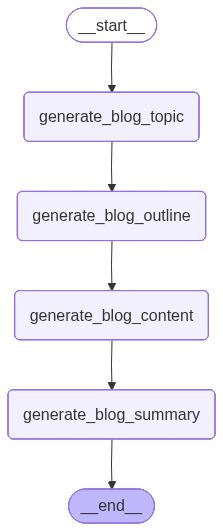

In [11]:
workflow = graph.compile()
workflow

#### Execution


In [12]:
final_state = workflow.invoke({})

In [13]:
console.print(Pretty(final_state["blog_topic"], justify="center"))


                                  'Exoplanets'                                  


In [14]:
Path("files").mkdir(exist_ok=True)

with open("./files/1-outline.md", "w") as f:
    f.write(final_state["blog_outline"])

console.print(Markdown(final_state["blog_content"]))


NameError: name 'Markdown' is not defined

In [ ]:
with open("./files/2-blog_content.md", "w") as f:
    f.write(final_state["blog_content"])

console.print(Markdown(final_state["blog_content"]))


In [ ]:
with open("./files/3-blog_summary.md", "w") as f:
    f.write(final_state["blog_summary"])

console.print(Markdown(final_state["blog_summary"]))
